# Reproduce Fig. 2(b): frozen surface modes on a moving interface

This notebook reconstructs the field map in Fig. 2(b) from the two uploaded papers.

**What is implemented**
- 2D moving-interface p-polarized reflection coefficient using the boosted rest-frame Fresnel coefficient.
- Weakly lossy Drude metal.
- Numerical search for the frozen-mode frequency.
- Angular-spectrum reconstruction of H_y(x,z) above the interface for an x-polarized line dipole at h = 0.05 λ0.

**Important note**
The papers provide the moving-interface reflection formalism and the qualitative description of Fig. 2, but they do not publish the exact source normalization, contour prescription, or original figure-generation code. So this notebook is a principled reconstruction rather than an exact recovery of the authors' internal notebook.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.special import hankel1

plt.rcParams['figure.dpi'] = 140
np.set_printoptions(precision=6, suppress=True)


## Model and helper functions

Units are normalized so that c = 1 and ω_p = 1. Then k_p = 1.


In [2]:
def sqrt_physical(z):
    z = np.asarray(z, dtype=np.complex128)
    out = np.sqrt(z)
    mask = np.imag(out) < 0
    out[mask] *= -1
    return out

def eps_drude(omega, wp=1.0, gamma_loss=0.0):
    omega = np.asarray(omega, dtype=np.complex128)
    return 1.0 - wp**2 / (omega * (omega + 1j * gamma_loss))

def lorentz_to_surface_frame(omega, kx, beta, c=1.0):
    gamma = 1.0 / np.sqrt(1.0 - beta**2)
    omega_p = gamma * (omega + beta * c * kx)
    kx_p = gamma * (kx + beta * omega / c)
    return omega_p, kx_p, gamma

def kz_vacuum(kx, omega, c=1.0):
    return sqrt_physical((omega / c)**2 - kx**2 + 0j)

def rp_rest(omega_p, kx_p, wp=1.0, gamma_loss=0.0, c=1.0):
    eps = eps_drude(omega_p, wp=wp, gamma_loss=gamma_loss)
    kz0 = sqrt_physical((omega_p / c)**2 - kx_p**2 + 0j)
    kzm = sqrt_physical(eps * (omega_p / c)**2 - kx_p**2 + 0j)
    return (eps * kz0 - kzm) / (eps * kz0 + kzm)

def rp_moving_2d(omega, kx, beta, wp=1.0, gamma_loss=0.0, c=1.0):
    omega_p, kx_p, _ = lorentz_to_surface_frame(omega, kx, beta, c=c)
    return rp_rest(omega_p, kx_p, wp=wp, gamma_loss=gamma_loss, c=c)


## Locate the frozen-mode frequency

For fixed v = 0.25c, the frozen mode is detected numerically from the collapse of the two positive-kx SPP peaks of |r_p|.


In [3]:
def positive_peak_positions(omega, beta=0.25, kx_max=2.5, n_k=5000):
    kx = np.linspace(1e-3, kx_max, n_k)
    rp = rp_moving_2d(omega, kx, beta=beta)
    score = np.log10(np.abs(rp) + 1e-12)
    peaks, props = find_peaks(score, prominence=0.15, distance=50)
    return kx, score, peaks, props

def estimate_omega_fsm(beta=0.25, omega_min=0.34, omega_max=0.42, n_omega=321):
    best = None
    for omega in np.linspace(omega_min, omega_max, n_omega):
        kx, score, peaks, _ = positive_peak_positions(omega, beta=beta)
        if len(peaks) >= 2:
            sep = kx[peaks[1]] - kx[peaks[0]]
            item = (sep, omega, kx[peaks[0]], kx[peaks[1]])
            if best is None or sep < best[0]:
                best = item
    if best is None:
        raise RuntimeError('Could not find two-peak regime. Expand omega range.')
    return {'omega_fsm': best[1], 'kx1': best[2], 'kx2': best[3], 'separation': best[0]}

fsm = estimate_omega_fsm(beta=0.25)
fsm


{'omega_fsm': np.float64(0.386),
 'kx1': np.float64(0.7143572714542908),
 'kx2': np.float64(0.7598481696339268),
 'separation': np.float64(0.04549089817963592)}

## Field reconstruction

The reflected field is reconstructed from a 2D angular spectrum,

H_y^refl(x,z) ∝ ∫ dk_x A_x(k_x) r_p(ω,k_x) exp(i k_x x) exp(i k_z (z+h)).

For the source spectrum we use an x-dipole motivated TM coupling factor

A_x(k_x) ∝ (k_z / k_0) exp(i k_z h).

The overall normalization is not essential because each panel is normalized to its own peak magnitude.


In [4]:
def source_spectrum_xdipole(kx, omega, h, c=1.0):
    kz = kz_vacuum(kx, omega, c=c)
    return (kz / (omega / c)) * np.exp(1j * kz * h)

def hy_reflected_map(omega, beta=0.25, gamma_loss=0.003, x_span_lambda=2.2, z_span_lambda=0.9,
                     nx=401, nz=181, kx_max=2.8, nk=3501, include_direct=True,
                     reflected_weight=3.0):
    c = 1.0
    lam0 = 2 * np.pi * c / omega
    h = 0.05 * lam0
    x = np.linspace(-x_span_lambda * lam0, x_span_lambda * lam0, nx)
    z = np.linspace(0.0, z_span_lambda * lam0, nz)
    X, Z = np.meshgrid(x, z)

    kx = np.linspace(-kx_max, kx_max, nk)
    kz = kz_vacuum(kx, omega, c=c)
    rp = rp_moving_2d(omega, kx, beta=beta, gamma_loss=gamma_loss, c=c)
    A = source_spectrum_xdipole(kx, omega, h, c=c)

    phase_x = np.exp(1j * np.outer(kx, x))
    phase_z = np.exp(1j * np.outer(kz, z + h))
    integrand = (A * rp)[:, None, None] * phase_x[:, :, None] * phase_z[:, None, :]
    H_refl = np.trapezoid(integrand, kx, axis=0).T / (2 * np.pi)

    H_total = reflected_weight * H_refl
    if include_direct:
        rho = np.sqrt(X**2 + (Z - h)**2) + 1e-12
        H_dir = -omega * (Z - h) / rho * hankel1(1, omega * rho)
        H_total = H_total + H_dir

    return {
        'x': x, 'z': z, 'lam0': lam0, 'h': h, 'kx': kx,
        'spectrum_z0': A * rp, 'H': H_total, 'H_refl': H_refl,
    }


## Choose the three frequencies

The paper compares one frequency below, one at, and one above the frozen-mode condition.


In [5]:
beta = 0.25
omega_fsm = fsm['omega_fsm']
omega_lo = omega_fsm - 0.020
omega_hi = omega_fsm + 0.020
omegas = [omega_hi, omega_fsm, omega_lo]
labels = [r'$\omega_0 > \omega_{\rm fsm}$', r'$\omega_0 = \omega_{\rm fsm}$', r'$\omega_0 < \omega_{\rm fsm}$']
print('omega_fsm ≈', omega_fsm)
print('Using:', omegas)


omega_fsm ≈ 0.386
Using: [np.float64(0.406), np.float64(0.386), np.float64(0.366)]


## Make a Fig. 2-style plot


C:\Users\xtliang\AppData\Local\Temp\ipykernel_4380\2692355060.py:10: RuntimeWarning: divide by zero encountered in divide
  return 1.0 - wp**2 / (omega * (omega + 1j * gamma_loss))
C:\Users\xtliang\AppData\Local\Temp\ipykernel_4380\2692355060.py:10: RuntimeWarning: invalid value encountered in divide
  return 1.0 - wp**2 / (omega * (omega + 1j * gamma_loss))
C:\Users\xtliang\AppData\Local\Temp\ipykernel_4380\2692355060.py:3: RuntimeWarning: invalid value encountered in sqrt
  out = np.sqrt(z)
C:\Users\xtliang\AppData\Local\Temp\ipykernel_4380\2692355060.py:25: RuntimeWarning: invalid value encountered in divide
  return (eps * kz0 - kzm) / (eps * kz0 + kzm)


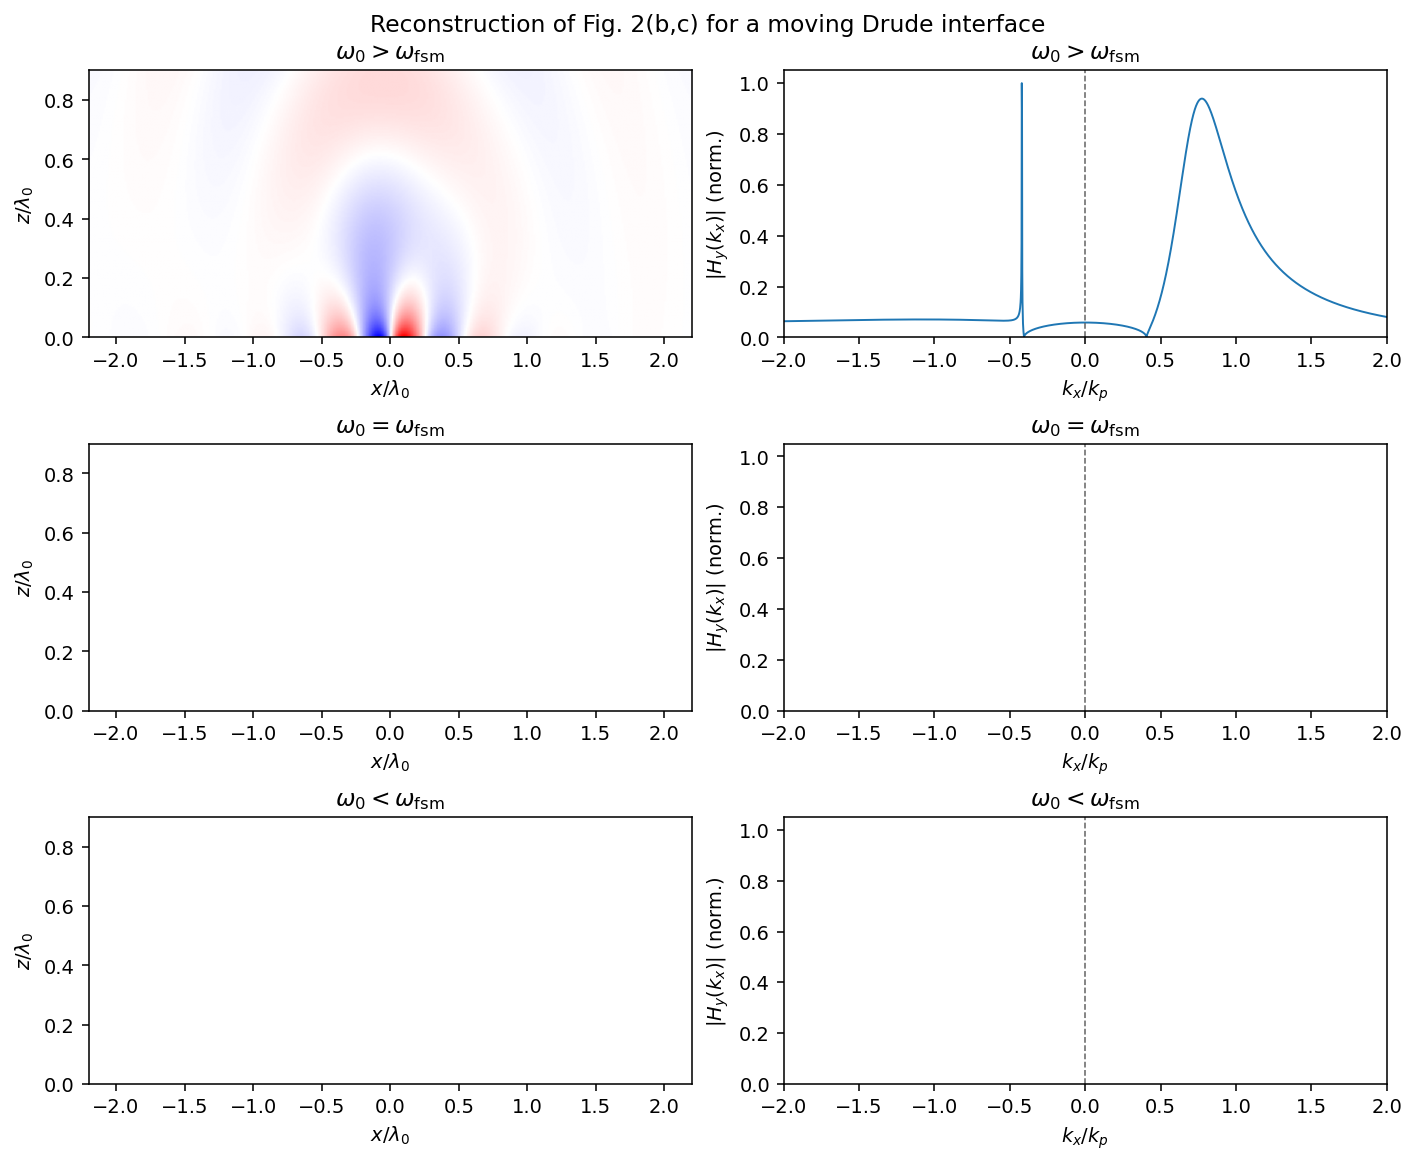

In [6]:
results = [hy_reflected_map(om, beta=beta, include_direct=True) for om in omegas]

fig, axes = plt.subplots(3, 2, figsize=(10, 8), constrained_layout=True)
for i, (res, label) in enumerate(zip(results, labels)):
    x = res['x'] / res['lam0']
    z = res['z'] / res['lam0']
    H = np.real(res['H'])
    H = H / np.max(np.abs(H))

    ax = axes[i, 0]
    ax.imshow(H, extent=[x.min(), x.max(), z.min(), z.max()], origin='lower', aspect='auto', cmap='bwr', vmin=-1, vmax=1)
    ax.set_title(label)
    ax.set_xlabel(r'$x/\lambda_0$')
    ax.set_ylabel(r'$z/\lambda_0$')

    spec = np.abs(res['spectrum_z0'])
    spec = spec / np.max(spec)
    ax2 = axes[i, 1]
    ax2.plot(res['kx'], spec, lw=1.0)
    ax2.axvline(0.0, ls='--', lw=0.8, color='0.4')
    ax2.set_xlim(-2.0, 2.0)
    ax2.set_ylim(0, 1.05)
    ax2.set_xlabel(r'$k_x/k_p$')
    ax2.set_ylabel(r'$|H_y(k_x)|$ (norm.)')
    ax2.set_title(label)

fig.suptitle('Reconstruction of Fig. 2(b,c) for a moving Drude interface', y=1.02)
plt.show()
